In [ ]:
!pip list -q

In [ ]:
!pip install seqeval evaluate -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
from datasets import load_dataset
from transformers import(
    AutoTokenizer,
    DataCollatorForTokenClassification,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
)
import evaluate

In [ ]:
dataset = load_dataset("mnaguib/WikiNER", "en")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.95k [00:00<?, ?B/s]

data/en/train.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

data/en/test.parquet:   0%|          | 0.00/1.57M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/129376 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14398 [00:00<?, ? examples/s]

In [ ]:
label_list = ["O", "LOC", "PER", "MISC", "ORG"]

id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

In [ ]:
model_checkpoint = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["words"],
        truncation=True,
        is_split_into_words=True
    )
    labels = []

    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100) # <--- SUDAH DIGANTI JADI -100 SESUAI TEORI LAPORAN!

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [ ]:
tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=True
)

Map:   0%|          | 0/129376 [00:00<?, ? examples/s]

Map:   0%|          | 0/14398 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
metric = evaluate.load("seqeval")

def compute_metrics(p):

  predictions, labels = p
  predictions = np.argmax(predictions, axis=2)

  true_predictions = [
      [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
  ]

  true_labels = [
      [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
  ]

  results = metric.compute(
      predictions = true_predictions,
      references=true_labels
  )

  return {
      "precision": results["overall_precision"],
      "recall": results["overall_recall"],
      "f1": results["overall_f1"],
      "accuracy": results["overall_accuracy"]
  }

In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer)

In [ ]:
training_args = TrainingArguments(
    output_dir="./xlm-roberta-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from datasets import DatasetDict

print("Memecah dataset menjadi Train, Validation, dan Test...")

#pisahkan 80% untuk Train, sisa 20% untuk cadangan
train_test_split = tokenized_dataset["train"].train_test_split(test_size=0.2, seed=42)

#pisahkan cadangan 20% tadi menjadi: 10% Validation, 10% Test
val_test_split = train_test_split["test"].train_test_split(test_size=0.5, seed=42)

#gabungin lg ke satu wadah bernama tokenized_dataset
tokenized_dataset = DatasetDict({
    "train": train_test_split["train"],
    "validation": val_test_split["train"],
    "test": val_test_split["test"]
})

print("Berhasil! Ukuran dataset sekarang:")
print(tokenized_dataset)

Memecah dataset menjadi Train, Validation, dan Test...
Berhasil! Ukuran dataset sekarang:
DatasetDict({
    train: Dataset({
        features: ['id', 'words', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 103500
    })
    validation: Dataset({
        features: ['id', 'words', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 12938
    })
    test: Dataset({
        features: ['id', 'words', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 12938
    })
})


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"] ,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.040426,0.043401,0.930569,0.926270,0.928415,0.987602


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.040426,0.043401,0.930569,0.926270,0.928415,0.987602
2,0.035057,0.036988,0.928341,0.946511,0.937338,0.989246
3,0.027756,0.039762,0.932986,0.947788,0.940329,0.989764


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=38814, training_loss=0.03648490259975629, metrics={'train_runtime': 6034.687, 'train_samples_per_second': 51.453, 'train_steps_per_second': 6.432, 'total_flos': 9695189180976000.0, 'train_loss': 0.03648490259975629, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate()

print(results)

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.027756,0.039762,3,0.932986,0.947788,0.940329,0.989764


{'eval_loss': 0.039762068539857864, 'eval_precision': 0.9329862980913062, 'eval_recall': 0.9477875030391442, 'eval_f1': 0.9403286597316448, 'eval_accuracy': 0.9897638120275208}


In [ ]:
trainer.save_model("./final-xlm-roberta-ner")
tokenizer.save_pretrained("./final-xlm-roberta-ner")

In [ ]:
from seqeval.metrics import classification_report
import numpy as np

correct_label_list = ["O", "LOC", "PER", "MISC", "ORG"]
correct_id2label = {i: label for i, label in enumerate(correct_label_list)}

def detailed_report_xlm_fixed(trainer, dataset_split):
    print("Menghitung detail prediksi untuk setiap kelas...")
    predictions_output = trainer.predict(dataset_split)
    logits = predictions_output.predictions
    label_ids = predictions_output.label_ids
    preds = np.argmax(logits, axis=-1)

    true_labels, true_preds = [], []
    for pred_seq, label_seq in zip(preds, label_ids):
        tl, tp = [], []
        for p, l in zip(pred_seq, label_seq):
            if l == -100:
                continue

            tl.append(correct_id2label[l])
            tp.append(correct_id2label[p])
        true_labels.append(tl)
        true_preds.append(tp)

    print("\nDetailed Per-Class Report (XLM-RoBERTa) - FIXED:")
    print(classification_report(true_labels, true_preds))

# Panggil fungsinya
detailed_report_xlm_fixed(trainer, tokenized_dataset["test"])

Menghitung detail prediksi untuk setiap kelas...



Detailed Per-Class Report (XLM-RoBERTa) - FIXED:
              precision    recall  f1-score   support

          ER       0.96      0.97      0.96      8740
          OC       0.91      0.93      0.92      7468

   micro avg       0.94      0.95      0.94     16208
   macro avg       0.93      0.95      0.94     16208
weighted avg       0.94      0.95      0.94     16208



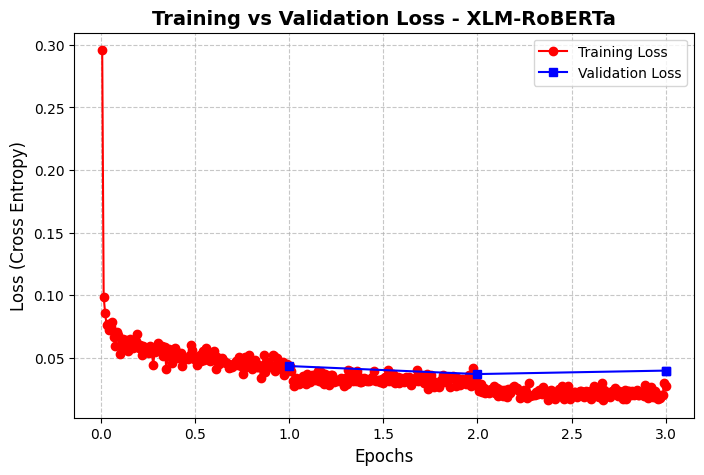

In [ ]:
import matplotlib.pyplot as plt

# =================================================================
# CELL VISUALISASI 1: KURVA TRAINING VS VALIDATION LOSS (HUGGING FACE)
# =================================================================

# Ambil riwayat training dari object trainer
log_history = trainer.state.log_history

train_epochs = []
train_loss = []
eval_epochs = []
eval_loss = []

# Ekstrak loss dari log
for log in log_history:
    if "loss" in log and "epoch" in log:
        train_loss.append(log["loss"])
        train_epochs.append(log["epoch"])
    if "eval_loss" in log and "epoch" in log:
        eval_loss.append(log["eval_loss"])
        eval_epochs.append(log["epoch"])

plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_loss, marker='o', linestyle='-', color='red', label='Training Loss')
plt.plot(eval_epochs, eval_loss, marker='s', linestyle='-', color='blue', label='Validation Loss')

plt.title('Training vs Validation Loss - XLM-RoBERTa', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Cross Entropy)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Menyiapkan Confusion Matrix...


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


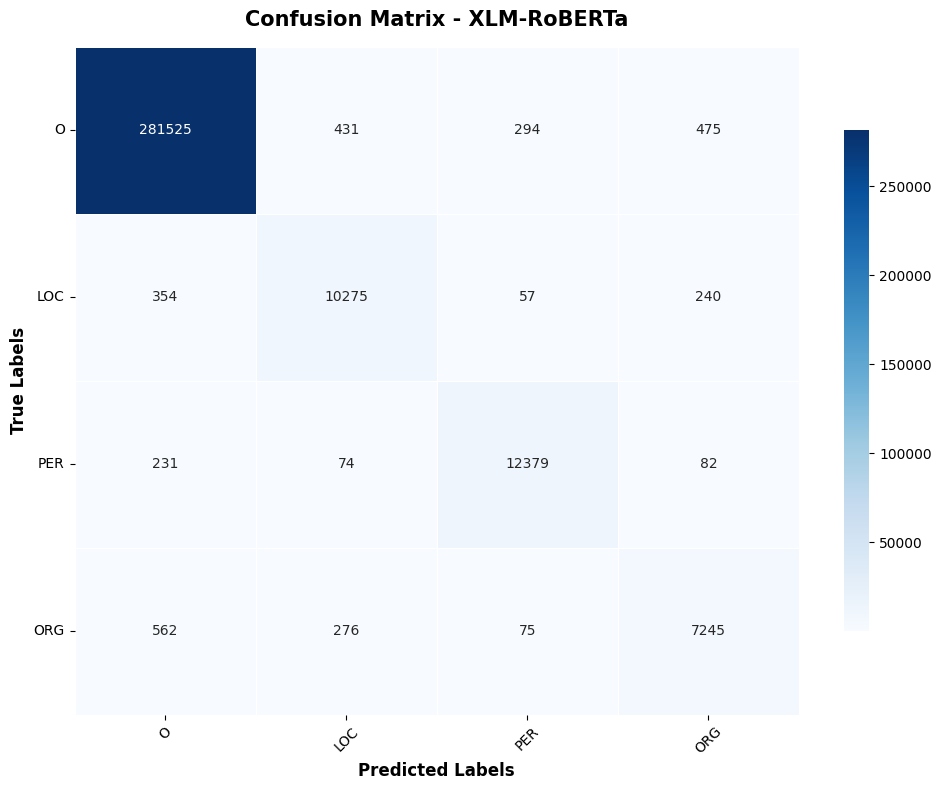

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# =================================================================
# CELL VISUALISASI 2: CONFUSION MATRIX
# =================================================================

print("Menyiapkan Confusion Matrix...")
predictions_output = trainer.predict(tokenized_dataset["test"])
logits = predictions_output.predictions
label_ids = predictions_output.label_ids
preds = np.argmax(logits, axis=-1)

flat_true = []
flat_pred = []

for pred_seq, label_seq in zip(preds, label_ids):
    for p, l in zip(pred_seq, label_seq):
        # Abaikan masking -100 dan padding
        if l != -100:
            flat_true.append(correct_id2label[l])
            flat_pred.append(correct_id2label[p])

labels_in_test = list(set(flat_true + flat_pred))
labels_in_test = [l for l in correct_label_list if l in labels_in_test]

cm = confusion_matrix(flat_true, flat_pred, labels=labels_in_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_in_test, yticklabels=labels_in_test,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title("Confusion Matrix - XLM-RoBERTa", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Predicted Labels", fontsize=12, fontweight='bold')
plt.ylabel("True Labels", fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Buka jalur ke Google Drive (kalau belum di-mount)
from google.colab import drive
drive.mount('/content/drive')

# 2. Lempar folder model XLM-RoBERTa ke Drive (Pake nama folder yang bener)
!cp -r ./final-xlm-roberta-ner /content/drive/MyDrive/XLM_RoBERTa_NER_Final
print("Model berhasil diamankan ke Google Drive!")

ValueError: mount failed